# Churn Analysis

## Importing libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Importing Dataset

In [3]:
df = pd.read_csv("..\\data\\house_sales.csv",sep="	")
df

,DocumentDate,SalePrice,PropertyID,PropertyType,ym,zhvi_px,zhvi_idx,AdjSalePrice,NbrLivingUnits,SqFtLot,...,Bathrooms,Bedrooms,BldgGrade,YrBuilt,YrRenovated,TrafficNoise,LandVal,ImpsVal,ZipCode,NewConstruction
1,2014-09-16,280000,1000102,Multiplex,2014-09-01,405100,0.930836,300805.0,2,9373,...,3.00,6,7,1991,0,0,70000,229000,98002,False
2,2006-06-16,1000000,1200013,Single Family,2006-06-01,404400,0.929228,1076162.0,1,20156,...,3.75,4,10,2005,0,0,203000,590000,98166,True
3,2007-01-29,745000,1200019,Single Family,2007-01-01,425600,0.977941,761805.0,1,26036,...,1.75,4,8,1947,0,0,183000,275000,98166,False
4,2008-02-25,425000,2800016,Single Family,2008-02-01,418400,0.961397,442065.0,1,8618,...,3.75,5,7,1966,0,0,104000,229000,98168,False
5,2013-03-29,240000,2800024,Single Family,2013-03-01,351600,0.807904,297065.0,1,8620,...,1.75,4,7,1948,0,0,104000,205000,98168,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27057,2011-04-08,325000,9842300710,Single Family,2011-04-01,318700,0.732307,443803.0,1,5468,...,1.75,3,7,1951,0,0,201000,172000,98126,False
27058,2007-09-28,1580000,9845500010,Single Family,2007-09-01,433500,0.996094,1586196.0,1,23914,...,4.50,4,11,2000,0,1,703000,951000,98040,False
27061,2012-07-09,165000,9899200010,Single Family,2012-07-01,325300,0.747472,220744.0,1,11170,...,1.00,4,6,1971,0,0,92000,130000,98055,False
27062,2006-05-26,315000,9900000355,Single Family,2006-05-01,400600,0.920496,342207.0,1,6223,...,2.00,3,7,1939,0,0,103000,212000,98166,False


## Data Inspection

In [4]:
df.head()

,DocumentDate,SalePrice,PropertyID,PropertyType,ym,zhvi_px,zhvi_idx,AdjSalePrice,NbrLivingUnits,SqFtLot,...,Bathrooms,Bedrooms,BldgGrade,YrBuilt,YrRenovated,TrafficNoise,LandVal,ImpsVal,ZipCode,NewConstruction
1,2014-09-16,280000,1000102,Multiplex,2014-09-01,405100,0.930836,300805.0,2,9373,...,3.00,6,7,1991,0,0,70000,229000,98002,False
2,2006-06-16,1000000,1200013,Single Family,2006-06-01,404400,0.929228,1076162.0,1,20156,...,3.75,4,10,2005,0,0,203000,590000,98166,True
3,2007-01-29,745000,1200019,Single Family,2007-01-01,425600,0.977941,761805.0,1,26036,...,1.75,4,8,1947,0,0,183000,275000,98166,False
4,2008-02-25,425000,2800016,Single Family,2008-02-01,418400,0.961397,442065.0,1,8618,...,3.75,5,7,1966,0,0,104000,229000,98168,False
5,2013-03-29,240000,2800024,Single Family,2013-03-01,351600,0.807904,297065.0,1,8620,...,1.75,4,7,1948,0,0,104000,205000,98168,False


In [5]:
df.info()

<class 'pandas.DataFrame'>
Index: 22687 entries, 1 to 27063
Data columns (total 22 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   DocumentDate     22687 non-null  str    
 1   SalePrice        22687 non-null  int64  
 2   PropertyID       22687 non-null  int64  
 3   PropertyType     22687 non-null  str    
 4   ym               22687 non-null  str    
 5   zhvi_px          22687 non-null  int64  
 6   zhvi_idx         22687 non-null  float64
 7   AdjSalePrice     22687 non-null  float64
 8   NbrLivingUnits   22687 non-null  int64  
 9   SqFtLot          22687 non-null  int64  
 10  SqFtTotLiving    22687 non-null  int64  
 11  SqFtFinBasement  22687 non-null  int64  
 12  Bathrooms        22687 non-null  float64
 13  Bedrooms         22687 non-null  int64  
 14  BldgGrade        22687 non-null  int64  
 15  YrBuilt          22687 non-null  int64  
 16  YrRenovated      22687 non-null  int64  
 17  TrafficNoise     22687 non-n

In [6]:
# Dataset Statistics
df.describe()

,SalePrice,PropertyID,zhvi_px,zhvi_idx,AdjSalePrice,NbrLivingUnits,SqFtLot,SqFtTotLiving,SqFtFinBasement,Bathrooms,Bedrooms,BldgGrade,YrBuilt,YrRenovated,TrafficNoise,LandVal,ImpsVal,ZipCode
count,2.268700e+04,2.268700e+04,22687.000000,22687.000000,2.268700e+04,22687.000000,2.268700e+04,22687.000000,22687.000000,22687.000000,22687.000000,22687.000000,22687.000000,22687.000000,22687.000000,2.268700e+04,2.268700e+04,22687.000000
mean,5.079244e+05,4.666164e+09,392181.923569,0.901153,5.652333e+05,1.018821,1.174633e+04,2080.165734,293.233305,2.176500,3.367744,7.680963,1971.195266,102.314762,0.205801,2.203211e+05,3.004712e+05,98078.526910
std,3.466368e+05,2.877700e+09,36349.866645,0.083525,3.854029e+05,0.159752,2.901602e+04,913.742170,439.454608,0.768027,0.904379,1.180464,30.313796,440.579006,0.554216,1.829177e+05,2.265750e+05,52.342559
min,3.000000e+03,1.000102e+06,311600.000000,0.715993,3.368000e+03,1.000000,4.940000e+02,370.000000,0.000000,0.000000,0.000000,3.000000,1900.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,98001.000000
25%,3.250000e+05,2.212325e+09,360700.000000,0.828814,3.605630e+05,1.000000,4.800000e+03,1420.000000,0.000000,1.750000,3.000000,7.000000,1950.000000,0.000000,0.000000,1.070000e+05,1.720000e+05,98034.000000
50%,4.246500e+05,4.006000e+09,403200.000000,0.926471,4.713150e+05,1.000000,7.200000e+03,1910.000000,0.000000,2.250000,3.000000,7.000000,1977.000000,0.000000,0.000000,1.820000e+05,2.460000e+05,98065.000000
75%,5.850000e+05,7.417700e+09,421200.000000,0.967831,6.494110e+05,1.000000,9.794000e+03,2540.000000,580.000000,2.500000,4.000000,8.000000,2000.000000,0.000000,0.000000,2.670000e+05,3.610000e+05,98117.000000
max,1.100000e+07,9.906000e+09,435200.000000,1.000000,1.164486e+07,5.000000,1.024068e+06,10740.000000,3500.000000,8.000000,33.000000,13.000000,2015.000000,2016.000000,3.000000,5.538000e+06,5.772000e+06,98354.000000


In [7]:
# is any of the data is missing
df.isnull().count()

DocumentDate       22687
SalePrice          22687
PropertyID         22687
PropertyType       22687
ym                 22687
zhvi_px            22687
zhvi_idx           22687
AdjSalePrice       22687
NbrLivingUnits     22687
SqFtLot            22687
SqFtTotLiving      22687
SqFtFinBasement    22687
Bathrooms          22687
Bedrooms           22687
BldgGrade          22687
YrBuilt            22687
YrRenovated        22687
TrafficNoise       22687
LandVal            22687
ImpsVal            22687
ZipCode            22687
NewConstruction    22687
dtype: int64

In [8]:
# Dropping this column not using regression analysis
df.drop(columns='NewConstruction',inplace=True)

In [9]:
df

,DocumentDate,SalePrice,PropertyID,PropertyType,ym,zhvi_px,zhvi_idx,AdjSalePrice,NbrLivingUnits,SqFtLot,...,SqFtFinBasement,Bathrooms,Bedrooms,BldgGrade,YrBuilt,YrRenovated,TrafficNoise,LandVal,ImpsVal,ZipCode
1,2014-09-16,280000,1000102,Multiplex,2014-09-01,405100,0.930836,300805.0,2,9373,...,0,3.00,6,7,1991,0,0,70000,229000,98002
2,2006-06-16,1000000,1200013,Single Family,2006-06-01,404400,0.929228,1076162.0,1,20156,...,1452,3.75,4,10,2005,0,0,203000,590000,98166
3,2007-01-29,745000,1200019,Single Family,2007-01-01,425600,0.977941,761805.0,1,26036,...,900,1.75,4,8,1947,0,0,183000,275000,98166
4,2008-02-25,425000,2800016,Single Family,2008-02-01,418400,0.961397,442065.0,1,8618,...,1640,3.75,5,7,1966,0,0,104000,229000,98168
5,2013-03-29,240000,2800024,Single Family,2013-03-01,351600,0.807904,297065.0,1,8620,...,0,1.75,4,7,1948,0,0,104000,205000,98168
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27057,2011-04-08,325000,9842300710,Single Family,2011-04-01,318700,0.732307,443803.0,1,5468,...,590,1.75,3,7,1951,0,0,201000,172000,98126
27058,2007-09-28,1580000,9845500010,Single Family,2007-09-01,433500,0.996094,1586196.0,1,23914,...,910,4.50,4,11,2000,0,1,703000,951000,98040
27061,2012-07-09,165000,9899200010,Single Family,2012-07-01,325300,0.747472,220744.0,1,11170,...,0,1.00,4,6,1971,0,0,92000,130000,98055
27062,2006-05-26,315000,9900000355,Single Family,2006-05-01,400600,0.920496,342207.0,1,6223,...,0,2.00,3,7,1939,0,0,103000,212000,98166


## Type Fixing
- Document Date: str -> DateTime
- YrBuilt: int64 -> DateTime
- YrRenovated: int64 -> DateTime
- ym(year-month): str -> DateTime
  
---
`Convert it into python object date because we do not need time in hrs`

In [10]:
df[df['YrBuilt'] ==0]

,DocumentDate,SalePrice,PropertyID,PropertyType,ym,zhvi_px,zhvi_idx,AdjSalePrice,NbrLivingUnits,SqFtLot,...,SqFtFinBasement,Bathrooms,Bedrooms,BldgGrade,YrBuilt,YrRenovated,TrafficNoise,LandVal,ImpsVal,ZipCode


In [28]:
# Type fixing
df1 = df.copy()
date_list = ['DocumentDate','ym']
for i in date_list:
    df1[i] = np.datetime64(df1[i], format='%Y-%m-%d')

year_list = ['YrBuilt','YrRenovated']

df1.loc[df1['YrRenovated'] == 0, 'YrRenovated'] = df1['YrBuilt']

for i in year_list:
    df1[i] = pd.to_datetime(df1[i],format='%Y')

TypeError: this function got an unexpected keyword argument 'format'

In [26]:
df1.info()

<class 'pandas.DataFrame'>
Index: 22687 entries, 1 to 27063
Data columns (total 21 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   DocumentDate     22687 non-null  datetime64[us]
 1   SalePrice        22687 non-null  int64         
 2   PropertyID       22687 non-null  int64         
 3   PropertyType     22687 non-null  str           
 4   ym               22687 non-null  datetime64[us]
 5   zhvi_px          22687 non-null  int64         
 6   zhvi_idx         22687 non-null  float64       
 7   AdjSalePrice     22687 non-null  float64       
 8   NbrLivingUnits   22687 non-null  int64         
 9   SqFtLot          22687 non-null  int64         
 10  SqFtTotLiving    22687 non-null  int64         
 11  SqFtFinBasement  22687 non-null  int64         
 12  Bathrooms        22687 non-null  float64       
 13  Bedrooms         22687 non-null  int64         
 14  BldgGrade        22687 non-null  int64         
 15  Y

In [27]:
df1.head()

,DocumentDate,SalePrice,PropertyID,PropertyType,ym,zhvi_px,zhvi_idx,AdjSalePrice,NbrLivingUnits,SqFtLot,...,SqFtFinBasement,Bathrooms,Bedrooms,BldgGrade,YrBuilt,YrRenovated,TrafficNoise,LandVal,ImpsVal,ZipCode
1,2014-09-16,280000,1000102,Multiplex,2014-09-01,405100,0.930836,300805.0,2,9373,...,0,3.00,6,7,1991-01-01,1991-01-01,0,70000,229000,98002
2,2006-06-16,1000000,1200013,Single Family,2006-06-01,404400,0.929228,1076162.0,1,20156,...,1452,3.75,4,10,2005-01-01,2005-01-01,0,203000,590000,98166
3,2007-01-29,745000,1200019,Single Family,2007-01-01,425600,0.977941,761805.0,1,26036,...,900,1.75,4,8,1947-01-01,1947-01-01,0,183000,275000,98166
4,2008-02-25,425000,2800016,Single Family,2008-02-01,418400,0.961397,442065.0,1,8618,...,1640,3.75,5,7,1966-01-01,1966-01-01,0,104000,229000,98168
5,2013-03-29,240000,2800024,Single Family,2013-03-01,351600,0.807904,297065.0,1,8620,...,0,1.75,4,7,1948-01-01,1948-01-01,0,104000,205000,98168


## Univariate Analysis

### Check the Following Cols

- SalePrice
- ym
- zhvi_px
- zhvi_idx
- AdjSalePrice
- NbrLivingUnits
- SqFtLot
- SqFtTotLiving
- SqFtFinBasement
- Bathrooms
- Bedrooms
- BldgGrade
- YrBuilt
- YrRenovated
- TrafficNoise
- LandVal
- ImpsVal

### Numerical Columns

#### Sales Price
- Data is positively Skewed

In [14]:
df['SalePrice'].describe()

count    2.268700e+04
mean     5.079244e+05
std      3.466368e+05
min      3.000000e+03
25%      3.250000e+05
50%      4.246500e+05
75%      5.850000e+05
max      1.100000e+07
Name: SalePrice, dtype: float64

In [15]:
(df['SalePrice'] < df['SalePrice'].quantile(q = .15)).sum()

np.int64(3393)

<Axes: ylabel='Frequency'>

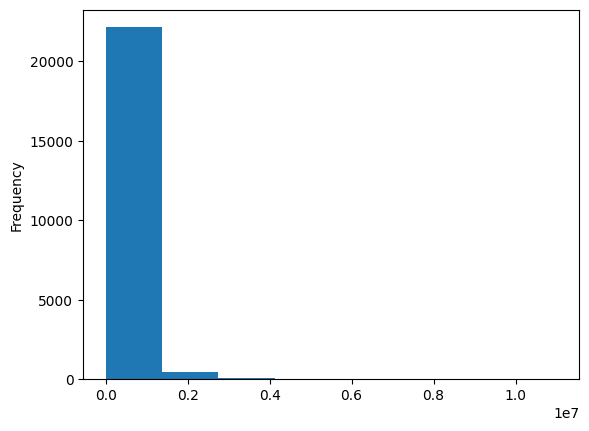

In [16]:
df['SalePrice'].plot(kind ='hist',bins = 8)

<Axes: ylabel='Density'>

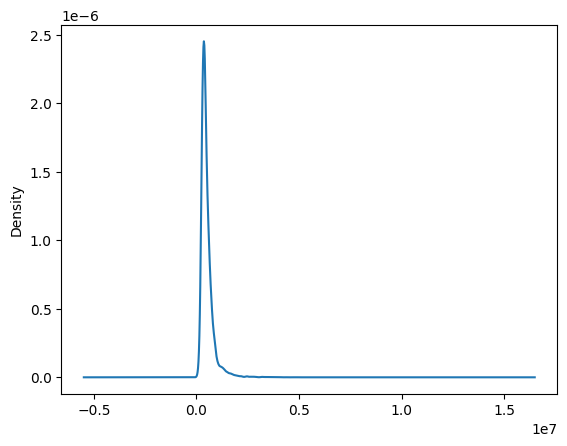

In [17]:
df['SalePrice'].plot(kind ='kde')

<Axes: xlabel='PropertyType'>

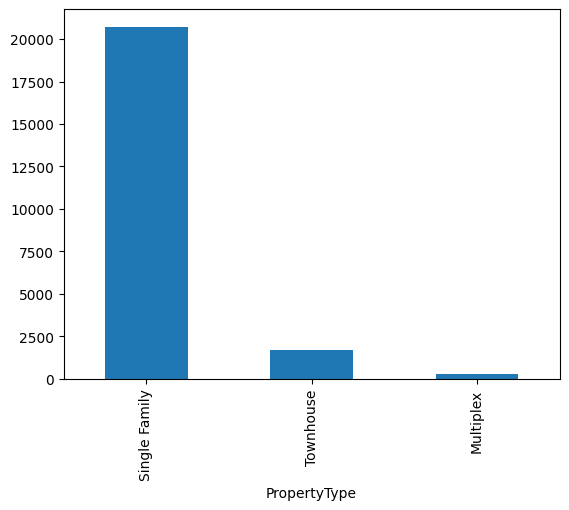

In [18]:
df['PropertyType'].value_counts().plot(kind = 'bar')

#### Year Month

In [19]:
df['ym']

1        2014-09-01
2        2006-06-01
3        2007-01-01
4        2008-02-01
5        2013-03-01
            ...    
27057    2011-04-01
27058    2007-09-01
27061    2012-07-01
27062    2006-05-01
27063    2007-01-01
Name: ym, Length: 22687, dtype: str

### Categorical Columns

<Axes: >

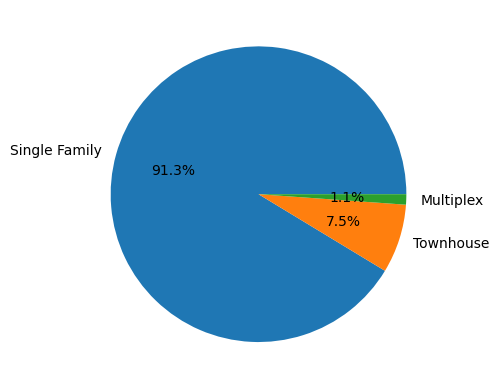

In [20]:
df['PropertyType'].value_counts().plot(kind='pie',autopct='%0.1f%%')